In [1]:
import pandas as pd

### Unzip the dataset

In [2]:
import zipfile
import os

zip_path = "dataset.zip"   # your file name
extract_path = "dataset"   # folder to extract

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [3]:
import os
os.listdir("dataset")

['cats_set', 'dogs_set']

### Load image dataset

In [4]:
import os

cats_path = "dataset/cats_set"
dogs_path = "dataset/dogs_set"

cats = os.listdir(cats_path)
dogs = os.listdir(dogs_path)

print("Cats images:", len(cats))
print("Dogs images:", len(dogs))

Cats images: 500
Dogs images: 500


### image show

(np.float64(-0.5), np.float64(497.5), np.float64(414.5), np.float64(-0.5))

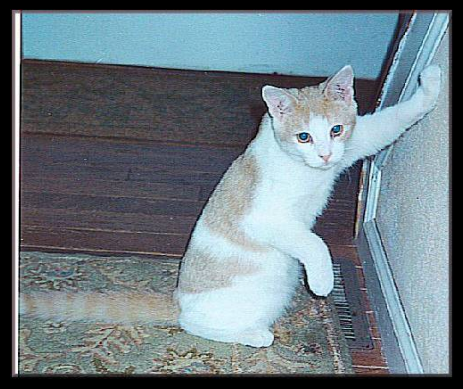

In [5]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open("dataset/cats_set/" + cats[0])
plt.imshow(img)
plt.axis("off")

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator

### Data Preprocessing

In [7]:
train_ds = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2   # 20% validation
)

### Load dataset from folder

In [8]:
# Generator
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(256, 256),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(256, 256),
    batch_size=32
)

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.


In [9]:
# Normalization Function
def process(image, label):
    # Pixel value 0-255 theke 0-1 range-e
    image = tf.cast(image / 255.0, tf.float32)
    return image, label
# Apply into the dataset
train_ds = train_ds.map(process)
val_ds = val_ds.map(process)

### Build Model (CNN)

In [10]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

C:\Users\khadiza.akter\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

### Compile model

In [12]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Train model

In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.5125 - loss: 0.8659 - val_accuracy: 0.4450 - val_loss: 0.6933
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.5612 - loss: 0.6772 - val_accuracy: 0.6250 - val_loss: 0.6565
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.6637 - loss: 0.6224 - val_accuracy: 0.5750 - val_loss: 0.6991
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.7550 - loss: 0.4848 - val_accuracy: 0.6350 - val_loss: 0.6987
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.8612 - loss: 0.3449 - val_accuracy: 0.6150 - val_loss: 0.8449


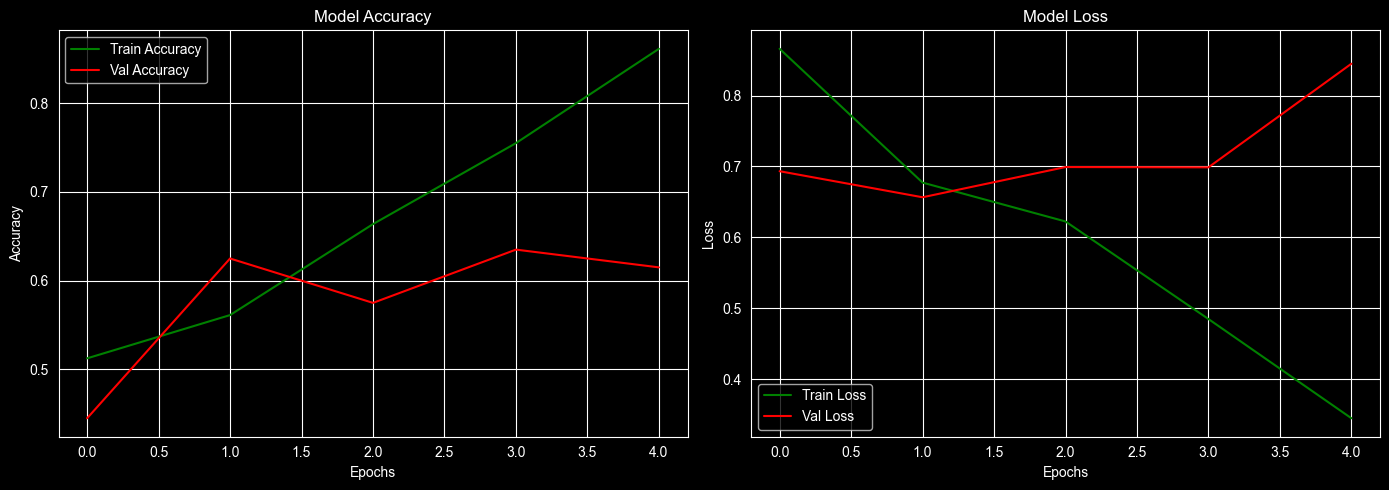

In [14]:
import matplotlib.pyplot as plt

# একটি ফিগারের ভেতরে দুটি গ্রাফ দেখানোর জন্য
plt.figure(figsize=(14, 5))

# ১. Accuracy গ্রাফ
plt.subplot(1, 2, 1) # ১টি সারিতে ২টি কলামের মধ্যে ১ নম্বর গ্রাফ
plt.plot(history.history['accuracy'], label='Train Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='red')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# ২. Loss গ্রাফ
plt.subplot(1, 2, 2) # ১টি সারিতে ২টি কলামের মধ্যে ২ নম্বর গ্রাফ
plt.plot(history.history['loss'], label='Train Loss', color='green')
plt.plot(history.history['val_loss'], label='Val Loss', color='red')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# গ্রাফগুলোর মাঝে যেন গ্যাপ থাকে
plt.tight_layout()
plt.show()

## Overfitting :

### ১. Dropout (ড্রপআউট)
মডেল ট্রেনিং করার সময় কিছু নিউরনকে রেন্ডমলি "বন্ধ" করে দেওয়া হয়। এতে মডেল কোনো নির্দিষ্ট তথ্য মুখস্থ না করে বরং ছবির আসল বৈশিষ্ট্যগুলো চিনতে শেখে।
> **কীভাবে:** `model.add(layers.Dropout(0.5))`

### ২. Data Augmentation (ডেটা বাড়ানো)
আপনার কাছে যদি ছবির সংখ্যা কম থাকে, তবে সেই ছবিগুলোকেই ঘুরিয়ে (Rotate), উল্টে (Flip) বা জুম (Zoom) করে নতুন নতুন ছবি তৈরি করা হয়। এতে মডেল অনেক বৈচিত্র্যময় ছবি দেখে শিখতে পারে।


### ৩. Early Stopping (আগে থামানো)
মডেল ট্রেনিং করার সময় যদি দেখা যায় **Validation Loss** আর কমছে না বরং বাড়ছে, তবে এই পদ্ধতি নিজে থেকেই ট্রেনিং থামিয়ে দেয়। এতে মডেলটি নষ্ট হওয়ার হাত থেকে বেঁচে যায়।


### ৪. Simplify Model (মডেল সহজ করা)
কখনও কখনও অনেক বেশি লেয়ার বা নিউরন থাকলে মডেল ওভারফিট করে। সেক্ষেত্রে লেয়ারের সংখ্যা কমিয়ে মডেলটিকে একটু ছোট ও সাধারণ রাখলে ভালো ফল পাওয়া যায়।

### ৫. Regularization (রেগুলারাইজেশন)
এটি মডেলের গাণিতিক হিসাব বা 'Weights' গুলোকে খুব বড় হতে দেয় না। এর ফলে মডেলটি খুব বেশি জটিল হয়ে ওঠে না এবং নতুন ডেটাতে ভালো কাজ করে।

---

**সহজ কথায় পরামর্শ:**
আপনি আপনার কোডে প্রথমে **Dropout (০.২ বা ০.৫)** যোগ করুন এবং **Epochs** সংখ্যা বাড়িয়ে (যেমন ২০) দেখুন। এতেই আপনার মডেলের পারফরম্যান্স অনেক উন্নত হবে।


### Overfitting

#### use Dropout & Early Stopping

In [15]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()

# ১. প্রথম কনভোলিউশন লেয়ার
model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

# ২. দ্বিতীয় কনভোলিউশন লেয়ার
model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

# ৩. তৃতীয় কনভোলিউশন লেয়ার
model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

# ৪. ডেন্স লেয়ার এবং ড্রপআউট (ওভারফিটিং কমানোর মূল চাবিকাঠি)
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))  # ২০% নিউরন রেন্ডমলি বন্ধ রাখবে

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))  # ১০% নিউরন রেন্ডমলি বন্ধ রাখবে

model.add(Dense(1, activation='sigmoid'))

# ৫. মডেল কম্পাইল
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ৬. আর্লি স্টপিং (লস বাড়লে অটোমেটিক ট্রেনিং থামিয়ে দিবে)
callback = EarlyStopping(monitor='val_loss', patience=3)

# ৭. মডেল ট্রেনিং (এখন ২০টি ইপোক দিয়ে রান করুন)
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[callback]
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.5437 - loss: 0.7708 - val_accuracy: 0.4350 - val_loss: 0.7103
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.5138 - loss: 0.6943 - val_accuracy: 0.5800 - val_loss: 0.6864
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.5425 - loss: 0.6873 - val_accuracy: 0.4550 - val_loss: 0.6942
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.5725 - loss: 0.6760 - val_accuracy: 0.5250 - val_loss: 0.6928
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.6562 - loss: 0.6208 - val_accuracy: 0.6150 - val_loss: 0.6737
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.7450 - loss: 0.5280 - val_accuracy: 0.6100 - val_loss: 0.7134
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.8125 - loss: 0.4253 - val_accuracy: 0.5650 - val_loss: 0.8873
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9000 - loss: 0.2517 - val_accuracy: 0.6800 - val_loss:

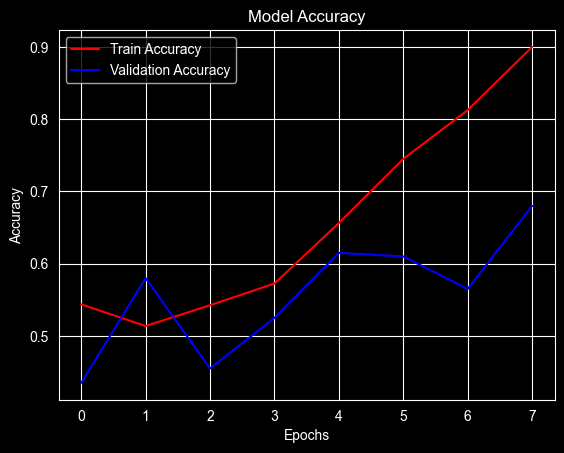

In [16]:
# ১. Accuracy প্লট করার জন্য
plt.plot(history.history['accuracy'], color='red', label='Train Accuracy')
plt.plot(history.history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

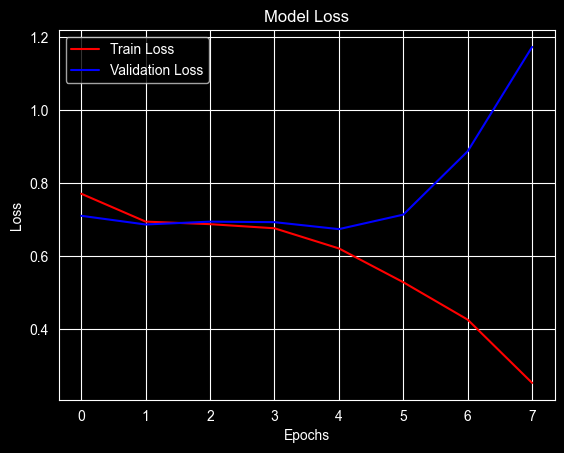

In [17]:
# ২. Loss প্লট করার জন্য
plt.plot(history.history['loss'], color='red', label='Train Loss')
plt.plot(history.history['val_loss'], color='blue', label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

#### BatchNormalization & Dropout

-> BatchNormalization layer-er output-ke ek-i scale-e niye ashe

In [18]:
from tensorflow.keras.layers import BatchNormalization, Dropout

model = Sequential()

# ১. প্রথম ব্লক
model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(BatchNormalization()) # Conv er porei BatchNormalization
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

# ২. দ্বিতীয় ব্লক
model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

# ৩. তৃতীয় ব্লক
model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

# ৪. ডেন্স লেয়ার (এখানে Dropout ব্যবহার করবেন)
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3)) # ৩০% নিউরন অফ রাখবে

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2)) # ২০% নিউরন অফ রাখবে

model.add(Dense(1, activation='sigmoid'))

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ৬. আর্লি স্টপিং (৫ ইপোক লস না কমলে বন্ধ হয়ে যাবে)
callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# ৭. মডেল ট্রেনিং (২০টি ইপোক দিয়ে শুরু করুন)
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[callback]
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 74s 3s/step - accuracy: 0.5375 - loss: 1.3080 - val_accuracy: 0.5650 - val_loss: 0.7341
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.6963 - loss: 0.7075 - val_accuracy: 0.5650 - val_loss: 0.7108
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.7738 - loss: 0.4897 - val_accuracy: 0.5750 - val_loss: 0.7564
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step - accuracy: 0.8413 - loss: 0.3678 - val_accuracy: 0.5650 - val_loss: 1.5891
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.8975 - loss: 0.2749 - val_accuracy: 0.5700 - val_loss: 0.8174
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.9062 - loss: 0.2324 - val_accuracy: 0.5650 - val_loss: 1.7938
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.9112 - loss: 0.2319 - val_accuracy: 0.5000 - val_loss: 0.9103


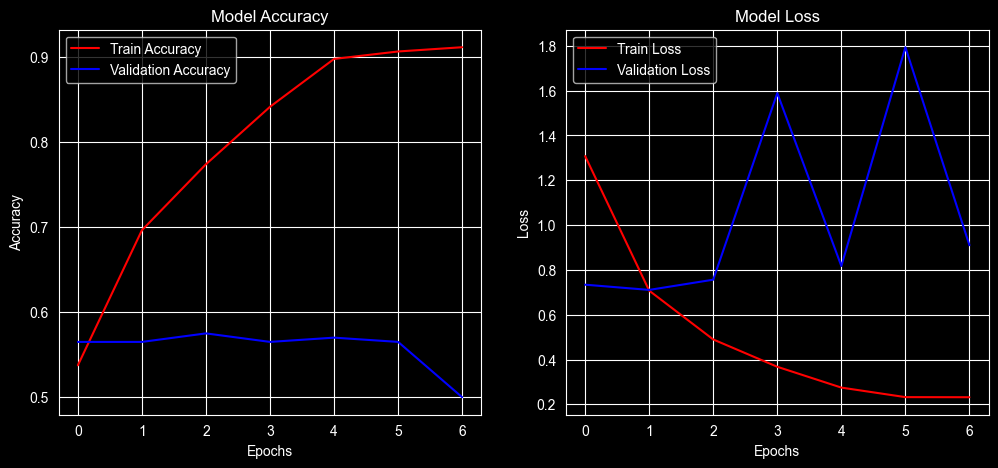

In [20]:
import matplotlib.pyplot as plt

# গ্রাফের সাইজ নির্ধারণ
plt.figure(figsize=(12, 5))

# ১. Accuracy প্লট করা
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='red', label='Train Accuracy')
plt.plot(history.history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# ২. Loss প্লট করা
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='red', label='Train Loss')
plt.plot(history.history['val_loss'], color='blue', label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

### VGG Model

In [21]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ১. VGG16 মডেল লোড করা (আগে থেকে শেখা জ্ঞানসহ)
conv_base = VGG16(
    weights='imagenet',
    include_top=False, # উপরের ডেন্স লেয়ারগুলো বাদ দিয়ে শুধু ফিচার এক্সট্রাক্টর নেওয়া
    input_shape=(256, 256, 3)
)

# ২. VGG16 এর লেয়ারগুলোকে লক করে দেওয়া (যাতে এগুলো নতুন করে ট্রেইন না হয়)
conv_base.trainable = False

# ৩. আমাদের নতুন মডেল তৈরি
model = Sequential()
model.add(conv_base) # আগে থেকে ট্রেইন হওয়া অংশ
model.add(Flatten()) # ছবিকে এক সারিতে আনা

# ৪. নতুন ডেন্স লেয়ার যোগ করা (আপনার ছবির জন্য শেখার অংশ)
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5)) # ওভারফিটিং কমানোর জন্য
model.add(Dense(1, activation='sigmoid')) # আউটপুট লেয়ার

# ৫. মডেল কম্পাইল করা (লার্নিং রেট একটু কমিয়ে রাখা ভালো)
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ৬. আর্লি স্টপিং (ভালো রেজাল্ট পেলে নিজ থেকেই থেমে যাবে)
callback = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# ৭. মডেল ট্রেনিং শুরু
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[callback]
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 262s 11s/step - accuracy: 0.6375 - loss: 0.6678 - val_accuracy: 0.7750 - val_loss: 0.4226
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 277s 11s/step - accuracy: 0.8750 - loss: 0.2956 - val_accuracy: 0.8900 - val_loss: 0.2818
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 257s 10s/step - accuracy: 0.9287 - loss: 0.1976 - val_accuracy: 0.9100 - val_loss: 0.2571
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 267s 11s/step - accuracy: 0.9400 - loss: 0.1627 - val_accuracy: 0.7850 - val_loss: 0.3818
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 278s 11s/step - accuracy: 0.9588 - loss: 0.1304 - val_accuracy: 0.9050 - val_loss: 0.2434
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 264s 11s/step - accuracy: 0.9762 - loss: 0.0897 - val_accuracy: 0.9050 - val_loss: 0.2450
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 270s 11s/step - accuracy: 0.9900 - loss: 0.0651 - val_accuracy: 0.9050 - val_loss: 0.2391
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 256s 10s/step - accuracy: 0.9925 - loss: 0.0547 - val_accuracy: 0.

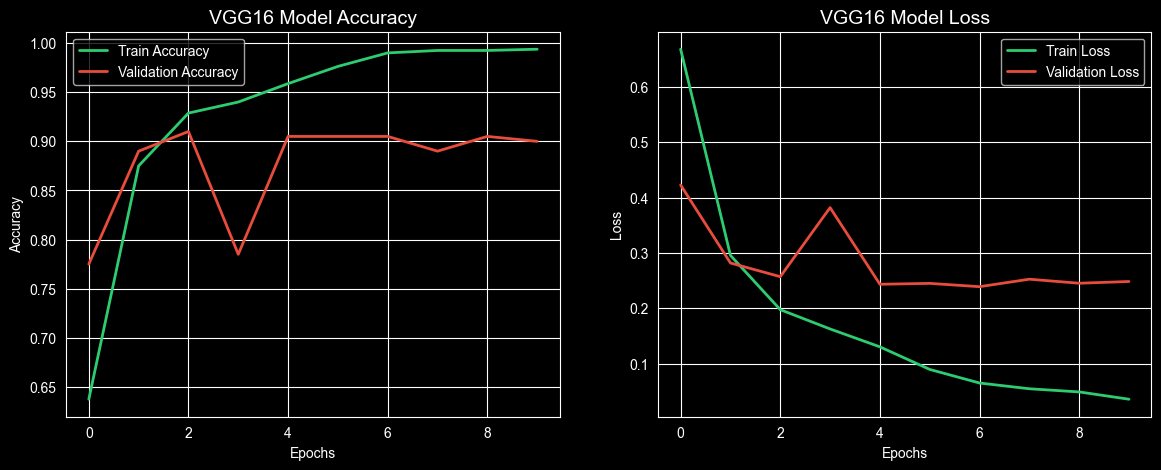

In [22]:
import matplotlib.pyplot as plt

# গ্রাফের সাইজ নির্ধারণ
plt.figure(figsize=(14, 5))

# ১. Accuracy প্লট করা
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='#2ecc71', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#e74c3c', linewidth=2)
plt.title('VGG16 Model Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# ২. Loss প্লট করা
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='#2ecc71', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#e74c3c', linewidth=2)
plt.title('VGG16 Model Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

### Prediction

In [23]:
import cv2

In [24]:
test_img = cv2.imread('C:/Users/khadiza.akter/Cat vs Dog Image Classification Project/dog.webp')

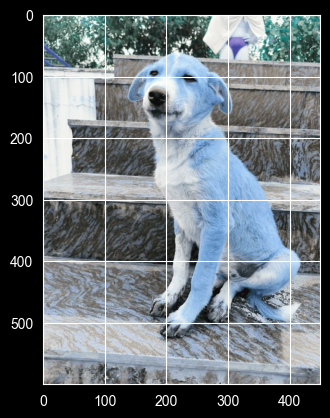

In [25]:
plt.imshow(test_img)

In [26]:
test_img.shape

(600, 450, 3)

In [27]:
test_img = cv2.resize(test_img, (256, 256))

In [28]:
test_img = test_img.reshape(1,256,256,3)

In [29]:
model.predict(test_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[1.]], dtype=float32)

In [30]:
test_img2 = cv2.imread('C:/Users/khadiza.akter/Cat vs Dog Image Classification Project/cat.jpg')

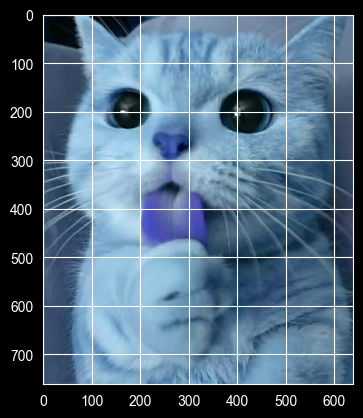

In [31]:
plt.imshow(test_img2)

In [32]:
test_img2.shape

(762, 640, 3)

In [33]:
test_img2 = cv2.resize(test_img2, (256, 256))

In [34]:
test_img2 = test_img2.reshape(1,256,256,3)

In [35]:
model.predict(test_img2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[0.]], dtype=float32)